In [14]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("xy_data.csv")
x_obs = df['x'].values
y_obs = df['y'].values

In [16]:
t = np.linspace(6, 60, len(df))

In [17]:
def curve(t, theta, M, X):
    theta_rad = np.deg2rad(theta)
    x_pred = t * np.cos(theta_rad) - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta_rad) + X
    y_pred = 42 + t * np.sin(theta_rad) + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta_rad)
    return x_pred, y_pred

In [18]:
def loss(params, t, x_obs, y_obs):
    theta, M, X = params
    x_pred, y_pred = curve(t, theta, M, X)
    error = np.sum(np.abs(x_obs - x_pred) + np.abs(y_obs - y_pred))

    print(f"Theta={theta:.4f}, M={M:.5f}, X={X:.4f}, Loss={error:.4f}")

    return error

In [19]:
initial_guess = [25, 0.0, 50]  # [theta, M, X]
bounds = [(0, 50), (-0.05, 0.05), (0, 100)]

In [20]:
result = minimize(loss, initial_guess, args=(t, x_obs, y_obs), bounds=bounds, method='L-BFGS-B')
theta_opt, M_opt, X_opt = result.x

Theta=25.0000, M=0.00000, X=50.0000, Loss=38501.5075
Theta=25.0000, M=0.00000, X=50.0000, Loss=38501.5075
Theta=25.0000, M=0.00000, X=50.0000, Loss=38501.5075
Theta=25.0000, M=0.00000, X=50.0000, Loss=38501.5075
Theta=50.0000, M=0.05000, X=100.0000, Loss=77326.9963
Theta=50.0000, M=0.05000, X=100.0000, Loss=77326.9963
Theta=50.0000, M=0.05000, X=100.0000, Loss=77326.9962
Theta=50.0000, M=0.05000, X=100.0000, Loss=77326.9963
Theta=27.1207, M=0.00424, X=54.2415, Loss=37924.0206
Theta=27.1207, M=0.00424, X=54.2415, Loss=37924.0206
Theta=27.1207, M=0.00424, X=54.2415, Loss=37924.0205
Theta=27.1207, M=0.00424, X=54.2415, Loss=37924.0206
Theta=27.7213, M=0.05000, X=55.4400, Loss=39034.0389
Theta=27.7213, M=0.05000, X=55.4400, Loss=39034.0389
Theta=27.7213, M=0.05000, X=55.4400, Loss=39034.0372
Theta=27.7213, M=0.05000, X=55.4400, Loss=39034.0389
Theta=27.2982, M=0.01776, X=54.5957, Loss=37879.8419
Theta=27.2982, M=0.01776, X=54.5957, Loss=37879.8419
Theta=27.2982, M=0.01776, X=54.5957, Loss=

In [21]:
print("\n OPTIMIZATION COMPLETE")
print(f"Theta (°) = {theta_opt:.4f}")
print(f"M         = {M_opt:.5f}")
print(f"X         = {X_opt:.4f}")


 OPTIMIZATION COMPLETE
Theta (°) = 28.1209
M         = 0.02140
X         = 54.9011


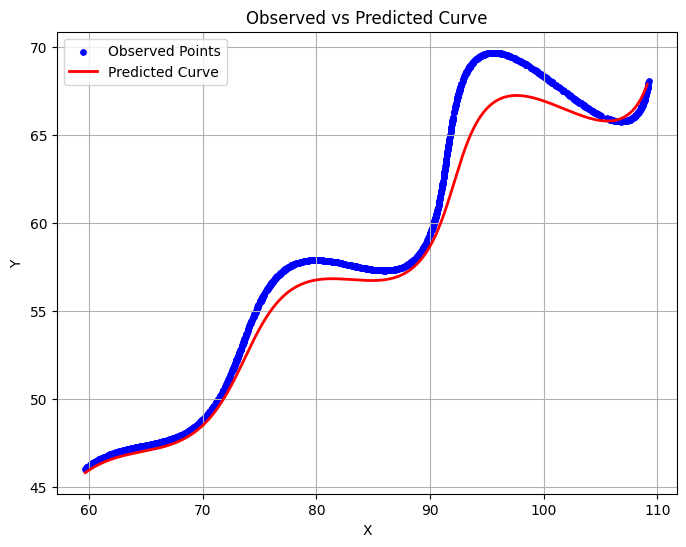

In [22]:
x_pred, y_pred = curve(t, theta_opt, M_opt, X_opt)

plt.figure(figsize=(8, 6))
plt.scatter(x_obs, y_obs, label="Observed Points", color='blue', s=15)
plt.plot(x_pred, y_pred, label="Predicted Curve", color='red', linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Observed vs Predicted Curve")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print("\n Final Equation:")
print(f"(t*cos({theta_opt:.4f}) - exp({M_opt:.5f}*|t|)*sin(0.3*t)*sin({theta_opt:.4f}) + {X_opt:.4f}, "
      f"42 + t*sin({theta_opt:.4f}) + exp({M_opt:.5f}*|t|)*sin(0.3*t)*cos({theta_opt:.4f}))")


 Final Equation:
(t*cos(28.1209) - exp(0.02140*|t|)*sin(0.3*t)*sin(28.1209) + 54.9011, 42 + t*sin(28.1209) + exp(0.02140*|t|)*sin(0.3*t)*cos(28.1209))
